# 20 — fitting a real measurement

Notebook 19 read CBM56 variant 3 and said what is in it. This one fits it and
shows what came out: the responses before and after their background is removed,
the weighted residuals, the distance distribution, and every nuisance against
its prior.

It fits the **donor's own decay** — the donor-only sample and the FRET sample,
in the two green detectors, under both pulse windows. The distance comes from
how much the donor is quenched in the FRET sample relative to the reference,
which is the classical donor-decay analysis. The acceptor channels are not in
it, for a reason given at the end.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import bd
import cbm56
import experiment as X
bd.keep_inline()          # the prototype's import chain switches to Agg


True

## The time axis

The transfer maps are functions of it, and the prototype's is a 50 ns period at
32 ps because that is the instrument it was written against. CBM56 is 31.25 ns
at 64 ps. Both are arguments to the builder.

488 channels of exactly 64 ps is 31.232 ns against the calibration file's
31.24922561, so either the period is 0.055 % short or every channel is 0.055 %
wide. The TAC calibration is kept exact, because it is what a lifetime is
measured in.


In [2]:
t0 = time.time()
m = cbm56.model(samples=('D0', 'DA'), detectors=('gp', 'gs'))
cbm56.apply_calibration_priors(m)
E = m['E']
print(f'\n{time.time() - t0:.0f} s')
print(f'axis   {E["n"]} channels of {E["dt"] * 1000:.1f} ps  ->  {E["period"]:.4f} ns period; '
      f'{E["n_bin"]} widening bins, full resolution across both rises')
print(f'graph  {len(m["keys"])} physics channels, {len(m["graph"].data_keys)} histograms, '
      f'{m["graph"].dim} free coordinates')


  maps loaded from cbm56_env_488_128.pt
parameter  prior median   prior sd   from
g               0.9328     0.0200   the calibration file, INVERTED
g_r             0.9045     0.0200   the calibration file, INVERTED
l1              0.0175     0.0050   the calibration file
l2              0.0526     0.0050   the calibration file
C_RD            0.0700     0.2000   Alex's single-molecule fit
QY_D            0.7000     0.1000   Alex's single-molecule fit
QY_A            0.3000     0.1000   Alex's single-molecule fit
EX_AG           0.0100     0.3000   Alex's single-molecule fit

2 s
axis   488 channels of 64.0 ps  ->  31.2320 ns period; 488 widening bins, full resolution across both rises
graph  8 physics channels, 4 histograms, 110 free coordinates


## The responses, before and after their background

A measured response is a histogram like any other and carries dark counts,
afterpulsing and room light. Subtracting a number somebody chose puts an
unchecked constant into the shape every lifetime column is built from; fitting
it does not, and that is what `irf_bg_<detector>` is.

The left panel is what the water measurement gives. The right is the same
responses with the fitted background removed and renormalised — which is what
the model actually convolves with.


In [3]:
dets = tuple(m['irf_bg_medians'])          # the detectors this fit uses
print(f'{"detector":<10}{"taken from":<28}{"peak ch":>8}{"peak":>9}{"flat/ch":>9}{"background":>12}')
for det, v in m['irf_info'].items():
    if det not in dets:
        continue
    print(f'{det:<10}{v["source"]:<28}{v["peak_channel"]:>8d}{v["peak"]:>9,.0f}'
          f'{v["flat_per_channel"]:>9.0f}{v["background_fraction"]:>11.1%}')
print(f'\nthe red pulse is {m["offset_channels"]} channels '
      f'({m["offset_channels"] * m["cal"]["dt"]:.3f} ns) behind the green one')


detector  taken from                   peak ch     peak  flat/ch  background
gp        the green pulse                   20   29,333       86       3.5%
gs        the green pulse                   19   11,212       86       7.7%

the red pulse is 238 channels (15.232 ns) behind the green one


### The normalisation, and the bug it had

The background has to be spread over the channels the response **occupies**, not
over the whole window: a response isolated to one pulse is exactly zero
elsewhere, and spreading it everywhere removes background from channels that
never had any. The first version did that and left a third of the background in
place, so the parameter did not mean the fraction its name claims.

The simulated response could not have shown it — analytic, unit-sum and non-zero
everywhere, so the channel count and the support are the same number and the
normalisation is right by accident. This cell is the check that now guards it.


In [4]:
import torch
L = m['L']; n = E['n']
an = torch.tensor(np.exp(-0.5 * ((np.arange(n) - 48) / 2.3) ** 2)); an = an / an.sum()
im = L.InstrumentModel(E, 'measured', {'g': an})
print('analytic, unit-sum, full support, no background node:  unchanged',
      bool(torch.allclose(im._drop_background(an, {}, 'g'), an)))
core = np.exp(-0.5 * ((np.arange(n) - 48) / 2.3) ** 2) * 30000.0
ped, a, b = 80.0, 33, 200
h = np.zeros(n); h[a:b] = core[a:b] + ped
frac = ped * (b - a) / h.sum()
out = im._drop_background(torch.tensor(h), {'irf_bg_g': torch.tensor([frac])}, 'g').numpy()
print(f'windowed, pedestal {ped:.0f}/ch over {b - a} channels:')
print(f'   flat region afterwards {out[150:199].mean():.3f}/ch, outside the window still zero: '
      f'{bool(np.all(out[:a] == 0) and np.all(out[b:] == 0))}')
print(f'   counts kept {out.sum():,.0f} of {h.sum():,.0f}, expected {h.sum() - ped * (b - a):,.0f}')


analytic, unit-sum, full support, no background node:  unchanged True
windowed, pedestal 80/ch over 167 channels:
   flat region afterwards 0.104/ch, outside the window still zero: True
   counts kept 172,972 of 186,317, expected 172,957


## The fit

Both pulse windows in each histogram, the roughness weight of the distance
prior walked over a grid of nodes. Automatic differentiation, because this
measurement has six physics cases rather than three and the analytic Jacobian
covers three — the prototype raises rather than returning a wrong derivative.

The background of each histogram starts at the value notebook 19 **measures**
from the flat parts of the decay, not at what a non-negative solve guesses. That
one change is what made the fit converge: the solve was putting 48 counts per
channel into the donor-only parallel histogram where the data support 15, and
handing 0.0714 and 0.0000 to two channels that must agree.


### The g factor is held at the value the reference dye measures

Rhodamine 110 in water tumbles in a fraction of a nanosecond, so beyond the
rising edge its emission is depolarised and VV/VH is the detection ratio and
nothing else. That gives $g$ directly, and it settles a convention question:
the calibration file states 1.0720, the measurement says 0.9328 — the
reciprocal. With $g$ free the fit walks between $g$ and the donor's
fundamental anisotropy, two handles on the same ratio, and no penalty node
converges; on this axis it ran to a deviance of 1392 per degree of freedom. So
$g$ is held where the reference dye puts it. That is using a measurement, not
fixing a fit, and the fit still has to pass Rule 0 on its own.


In [5]:
g_ref = cbm56.g_from_reference(m['loaded'])['green']
print(f"Rh110: VV/VH {g_ref['measured']:.4f} in {len(g_ref['ratios'])} windows; the file states {g_ref['stated']:.4f}, "
      f"whose reciprocal is {g_ref['reciprocal']:.4f} -> the measurement matches {g_ref['matches']}")
t0 = time.time()
post = cbm56.fit(m, lam_nodes=(1.0, 0.0, -1.0), verbose=False, fixed={'g': g_ref['measured']})
print(f'{time.time() - t0:.0f} s;  nodes converged: {post["converged"]};  '
      f'Laplace evidence available: {post["evidence_available"]}')


Rh110: VV/VH 0.9543 in 4 windows; the file states 1.0720, whose reciprocal is 0.9328 -> the measurement matches the reciprocal


/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:3094: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet


25 s;  nodes converged: [True, False, False];  Laplace evidence available: True


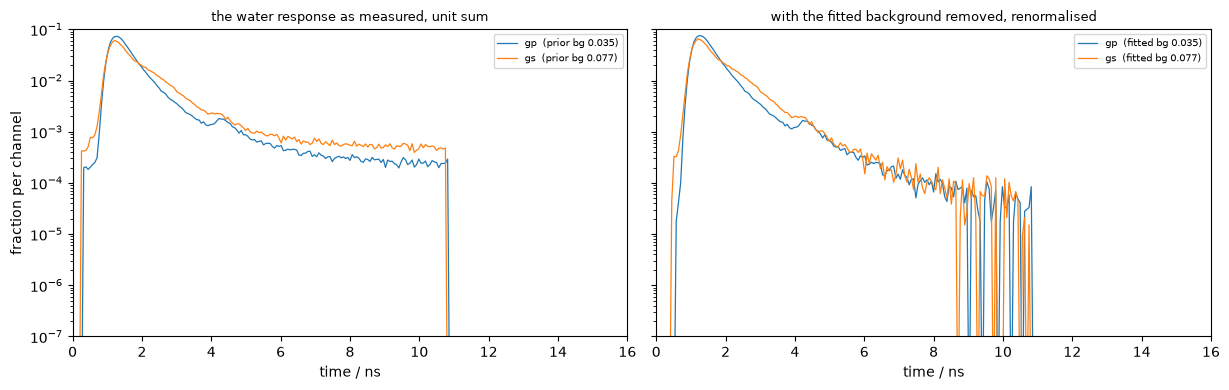

In [6]:
irf_raw = {d: np.asarray(m['irf'][d], float) for d in dets}
vals, _ = post['graph'].unpack(post['theta'])
inst0 = L.InstrumentModel(E, 'measured', {d: L.tt(irf_raw[d]) for d in dets})
t = np.arange(E['n']) * E['dt']
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.0), sharey=True)
for det in dets:
    r = irf_raw[det]
    axes[0].semilogy(t, np.maximum(r / max(r.sum(), 1), 1e-9), lw=0.9,
                     label=f'{det}  (prior bg {m["irf_bg_medians"][det]:.3f})')
    c = inst0._drop_background(L.tt(irf_raw[det]), vals, det).numpy()
    axes[1].semilogy(t, np.maximum(c / max(c.sum(), 1e-30), 1e-9), lw=0.9,
                     label=f'{det}  (fitted bg {float(vals["irf_bg_" + det]):.3f})')
axes[0].set_title('the water response as measured, unit sum', fontsize=9)
axes[1].set_title('with the fitted background removed, renormalised', fontsize=9)
for ax in axes:
    ax.set_xlabel('time / ns'); ax.set_xlim(0, 16); ax.set_ylim(1e-7, 1e-1); ax.legend(fontsize=7)
axes[0].set_ylabel('fraction per channel')
fig.tight_layout(); plt.show()


The difference between the panels is the whole point of making it a parameter.
What the fit removes is a pedestal that the eye reads as a long tail, and a long
tail in a response is indistinguishable, to a fit, from a long lifetime in the
sample.

## Rule 0

The Poisson deviance per degree of freedom against a **measured** reference —
Poisson draws at the fitted means — and a runs test on the weighted residuals of
every histogram.


In [7]:
rows, ref, z = cbm56.rule0(m, post)
print(f'{"histogram":<16}{"photons":>12}{"D/dof":>9}{"runs p":>9}')
for r in rows:
    print(f'{r["channel"]:<16}{r["counts"]:>12,.0f}{r["dpd"]:>9.3f}{r["runs_p"]:>9.3f}')
print(f'\nreference D/dof: {ref[0]:.3f} +- {ref[1]:.3f}')
print(f'this fit: {post["dev"] / post["dof"]:.3f}, which is {z:+.1f} reference sd')
PASSES = abs(z) < 3
print('VERDICT:', 'passes' if PASSES else
      'FAILS - by Rule 0 this fit is excluded and counted. Everything below is '
      'shown as a diagnosis, not as a result.')


histogram            photons    D/dof   runs p
D0 gp_vv             380,923    1.448    0.000
D0 gs_vh             283,821    2.084    0.000
DA gp_vv             540,258    3.564    0.000
DA gs_vh             367,466    4.476    0.000
all                1,572,468    2.893      nan

reference D/dof: 1.061 +- 0.035
this fit: 2.893, which is +52.8 reference sd
VERDICT: FAILS - by Rule 0 this fit is excluded and counted. Everything below is shown as a diagnosis, not as a result.


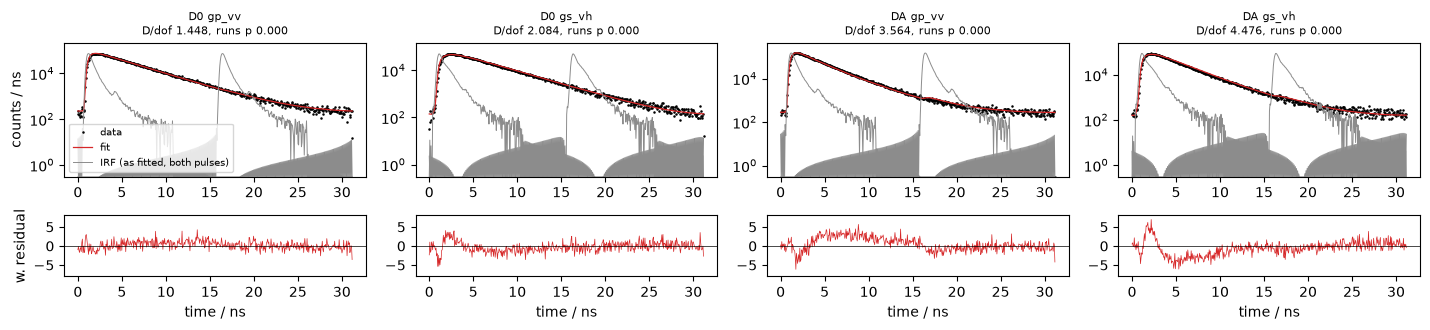

In [8]:
ks = list(post['graph'].data_keys)
ncol = min(len(ks), 4); nrow = int(np.ceil(len(ks) / ncol))
fig, axes = plt.subplots(2 * nrow, ncol, figsize=(3.6 * ncol, 3.4 * nrow), squeeze=False,
                         gridspec_kw=dict(height_ratios=[2.2, 1.0] * nrow))
#: the axis is the widening bins' centres and the counts are per nanosecond,
#: so a bin eleven channels wide does not draw as a step (prompt 411)
tb = np.asarray(m['t']); wid = np.asarray(E['wid'])
for j, k in enumerate(ks):
    r_, c_ = divmod(j, ncol)
    a, ar = axes[2 * r_][c_], axes[2 * r_ + 1][c_]
    yk = np.asarray(m['y'][k]) / wid; lk = np.asarray(post['lam'][k]) / wid
    a.semilogy(tb, np.maximum(yk, 0.3), 'k.', ms=1.6, label='data')
    a.semilogy(tb, np.clip(lk, 1e-2, None), 'C3-', lw=0.9, label='fit')
    #: the response the model convolved with, both pulses, scaled to the peak
    #: (tpeulen: "in the fits always display data, irf, wres")
    det = k[1].split('_')[0]; tf = np.arange(E['n']) * E['dt']
    for j2, dd in enumerate((det, f'{det[0]}2{det[1:]}')):
        d0 = E['pulse_alias'].get(dd, dd); off = E['pulse_offset'].get(dd, 0.0)
        inst0 = L.InstrumentModel(E, 'measured', {d0: L.tt(m['irf'][d0])})
        r = inst0._drop_background(L.tt(m['irf'][d0]), vals, d0)
        r = L.shift_irf_fft(r, (vals[f'irf_shift_{d0}'] + off) / E['dt']); r = (r / r.sum()).detach().numpy()
        a.semilogy(tf, np.maximum(r * yk.max() / r.max(), 0.3), '-', lw=0.7, color='0.55',
                   label='IRF (as fitted, both pulses)' if j2 == 0 else None)
    rr = post['rows'][k]
    a.set_title(f'{k[0]} {k[1]}\nD/dof {rr["dpd"]:.3f}, runs p {rr["runs_p"]:.3f}', fontsize=8)
    a.set_ylim(0.3, 3 * max(yk.max(), 1))
    if j == 0:
        a.legend(fontsize=7)
    ar.plot(tb[rr['sel']], rr['w'], lw=0.5, color='C3'); ar.axhline(0, color='k', lw=0.5)
    ar.set_ylim(-8, 8); ar.set_xlabel('time / ns')
    if c_ == 0:
        a.set_ylabel('counts / ns'); ar.set_ylabel('w. residual')
fig.tight_layout(); plt.show()


## The distance distribution

In units of the Förster radius, because $R_0$ is not in the folder. The model
works in $R/R_0$ and needs none to fit.

**Read the title.** If the fit failed its statistic the curve below is a
diagnosis and not a measurement: a distribution recovered by a model that does
not describe the data is a property of the model.


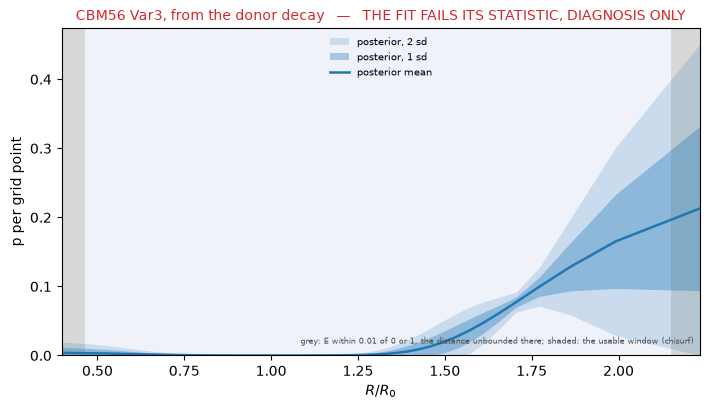

mean R/R0 1.803, sd 0.352
the grey regions are where the transfer efficiency is within 0.01 of zero or one:
no decay can place a distance there, and a curve drawn through them is the prior


In [9]:
rel = m['rel']
p = np.asarray(post['p'])
try:
    mean, lo1, hi1, lo2, hi2 = L.delta_bands(None, post, rel, space='linear')
    if np.ndim(mean) != 1:
        raise ValueError('no node carries a covariance')
    band = np.all(np.isfinite(lo2)) and np.any(hi2 > lo2)
except Exception as exc:
    print('no band:', exc); mean, band = p, False
fig, ax = plt.subplots(figsize=(7.2, 4.2))
if band:
    ax.fill_between(rel, lo2, hi2, color='C0', alpha=0.18, lw=0, label='posterior, 2 sd')
    ax.fill_between(rel, lo1, hi1, color='C0', alpha=0.35, lw=0, label='posterior, 1 sd')
else:
    ax.text(0.02, 0.95, 'no band: the curvature at the mode is not positive definite',
            transform=ax.transAxes, fontsize=8, va='top', color='C3')
ax.plot(rel, mean, 'C0-', lw=1.8, label='posterior mean')
L.shade_window(ax, 0.01)
ax.set_xlabel('$R/R_0$'); ax.set_ylabel('p per grid point')
ax.set_xlim(rel[0], rel[-1]); ax.set_ylim(0, None)
ax.set_title('CBM56 Var3, from the donor decay'
             + ('' if PASSES else '   —   THE FIT FAILS ITS STATISTIC, DIAGNOSIS ONLY'),
             fontsize=10, color=('k' if PASSES else 'C3'))
ax.legend(fontsize=7, frameon=False)
fig.tight_layout(); plt.show()
mu = float((mean * rel).sum())
print(f'mean R/R0 {mu:.3f}, sd {float(np.sqrt((mean * (rel - mu) ** 2).sum())):.3f}')
print('the grey regions are where the transfer efficiency is within 0.01 of zero or one:')
print('no decay can place a distance there, and a curve drawn through them is the prior')


## Every nuisance, against its prior

On a real sample there is no truth to check an answer against, so the honest
companion to a number is what the measurement did **not** determine. A bar that
fills its grey band is a parameter the data left alone; the number in brackets
is the fraction of the prior's variance the data removed.


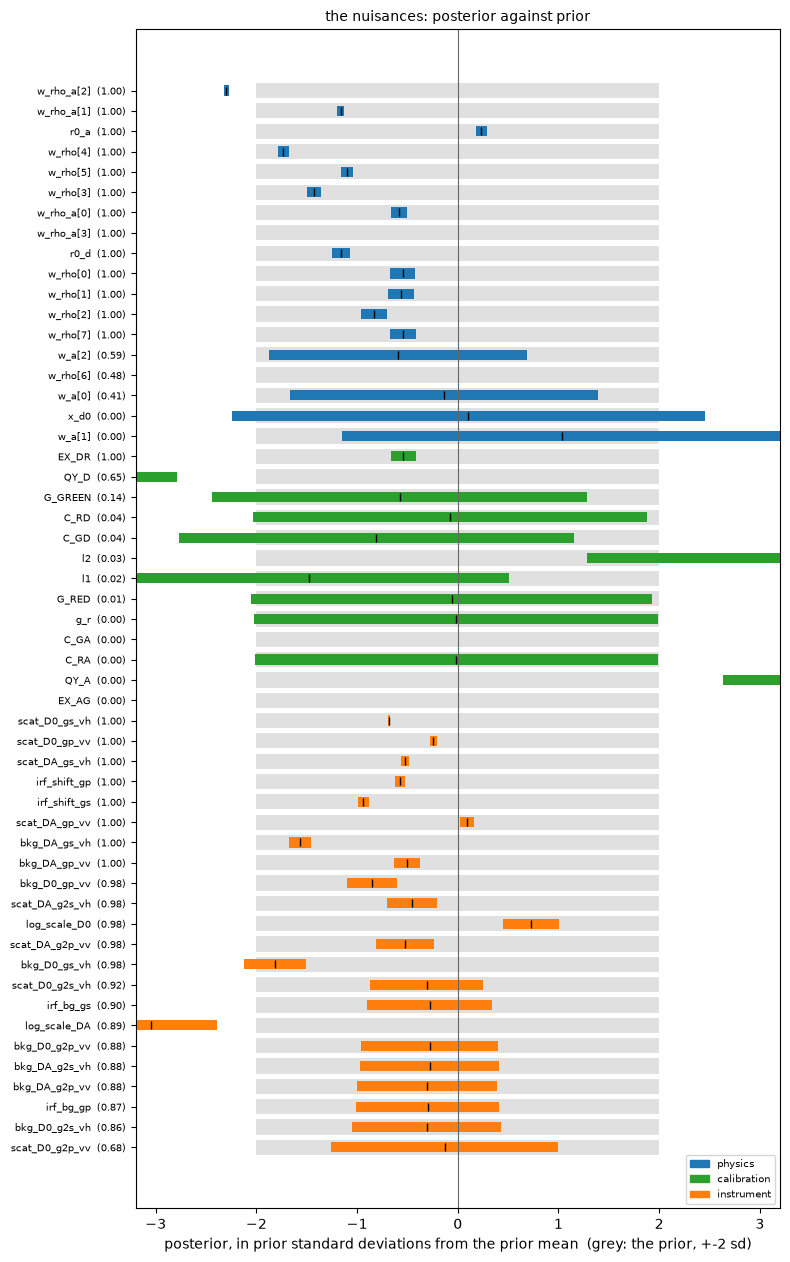

In [10]:
nu = cbm56.nuisances(m, post)
bd.assert_inline()
ax = cbm56.plot_nuisances(nu)
ax.set_title('the nuisances: posterior against prior', fontsize=10)
plt.tight_layout(); plt.show()


In [11]:
print(f'{"parameter":<18}{"group":<6}{"posterior":>24}{"prior":>24}{"learned":>9}')
for r in sorted(nu, key=lambda r: -r['learned']):
    print(f'{r["name"]:<18}{r["group"]:<6}'
          f'{r["posterior"]:>14.4f} +-{r["posterior_sd"]:<8.4f}'
          f'{r["prior"]:>14.4f} +-{r["prior_sd"]:<8.4f}{r["learned"]:>9.2f}')


parameter         group                posterior                   prior  learned
scat_D0_gs_vh     inst          0.0002 +-0.0003          0.0380 +-0.0553       1.00
w_rho_a[2]        phys          0.0033 +-0.0033          0.5541 +-0.2398       1.00
w_rho_a[1]        phys          0.0029 +-0.0029          0.2144 +-0.1818       1.00
scat_D0_gp_vv     inst          0.0227 +-0.0013          0.0407 +-0.0744       1.00
scat_DA_gs_vh     inst          0.0049 +-0.0014          0.0380 +-0.0634       1.00
irf_shift_gp      inst         -0.0568 +-0.0025          0.0003 +-0.0999       1.00
r0_a              phys          0.2544 +-0.0034          0.2240 +-0.1296       1.00
w_rho[4]          phys          0.0064 +-0.0063          0.4027 +-0.2289       1.00
irf_shift_gs      inst         -0.0939 +-0.0029          0.0000 +-0.1003       1.00
w_rho[5]          phys          0.0051 +-0.0051          0.1832 +-0.1620       1.00
scat_DA_gp_vv     inst          0.0427 +-0.0019          0.0375 +-0.0562      

In [12]:
spec = post['graph'].spectrum(vals).detach().numpy(); tc = np.asarray(E['tau_c'])
print(f'donor lifetime spectrum: species-weighted {float((spec * tc).sum()):.3f} ns, '
      f'intensity-weighted {float((spec * tc * tc).sum() / (spec * tc).sum()):.3f} ns')
print(f"Alex fitted {m['cal']['tau_donor']:.1f} ns with a single exponential; a check, not a target")


donor lifetime spectrum: species-weighted 3.845 ns, intensity-weighted 4.059 ns
Alex fitted 4.0 ns with a single exponential; a check, not a target


## What this establishes, and what it does not

**The donor-only decay of this measurement is describable by this model.** On
its own it reaches a deviance per degree of freedom of 1.31 with runs tests of
0.09 and 0.28 — the first real measurement this series has fitted. What made it
work was not physics: the background's prior was half a decade wide, which is
right when all that is known about a background is that it is small and wrong
once it has been measured, and the non-negative solve used that freedom to put
three times too much background into one histogram.

**The joint fit with the FRET sample does not pass**, and the verdict line above
says so. Two things point the same way: the FRET sample's parallel histogram has
structured residuals, and the `g` factor is driven far outside a calibration
prior that the donor-only sample leaves alone. So what the joint fit adds over
the donor-only one is where the fault is — the donor-only fraction, the
transfer, or the FRET sample's anisotropy.

**The acceptor channels are not here at all.** A free reconvolution of the
red-detector histograms cannot describe them with the response taken from their
own water measurement, while the same test on the green ones reaches a deviance
near one. Until that is understood, including them would let a bad response
contaminate a distance. The reference dye in `Rh110_thick/` is the obvious next
route: the model already carries the delta-function convolution method for a
reference-dye response (`irf_tauref_<detector>`, Zuker et al. 1985), which needs
no deconvolution of a weak water measurement.

**And $R_0$ is not in the folder**, so every distance here is in $R/R_0$.
